In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.resnet50 import decode_predictions
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
import urllib, PIL
import numpy as np

In [ ]:
img = load_img('adolf.jpeg')

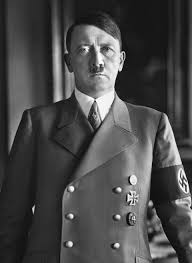

In [ ]:
img

In [ ]:
type(img)

PIL.JpegImagePlugin.JpegImageFile

In [ ]:
img_to_array(img)

array([[[32., 32., 32.],
        [30., 30., 30.],
        [27., 27., 27.],
        ...,
        [49., 49., 49.],
        [60., 60., 60.],
        [67., 67., 67.]],

       [[32., 32., 32.],
        [30., 30., 30.],
        [27., 27., 27.],
        ...,
        [49., 49., 49.],
        [60., 60., 60.],
        [67., 67., 67.]],

       [[32., 32., 32.],
        [30., 30., 30.],
        [27., 27., 27.],
        ...,
        [49., 49., 49.],
        [60., 60., 60.],
        [67., 67., 67.]],

       ...,

       [[27., 27., 27.],
        [28., 28., 28.],
        [29., 29., 29.],
        ...,
        [62., 62., 62.],
        [74., 74., 74.],
        [81., 81., 81.]],

       [[28., 28., 28.],
        [28., 28., 28.],
        [29., 29., 29.],
        ...,
        [58., 58., 58.],
        [73., 73., 73.],
        [82., 82., 82.]],

       [[28., 28., 28.],
        [29., 29., 29.],
        [29., 29., 29.],
        ...,
        [56., 56., 56.],
        [72., 72., 72.],
        [82., 82., 82.]]

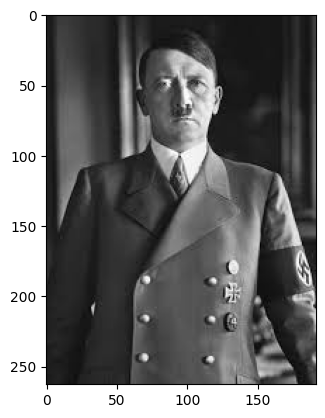

In [ ]:
import matplotlib.pyplot as plt
import cv2
plt.imshow(img)

In [ ]:
img = img_to_array(img)

In [ ]:
img.shape

(263, 192, 3)

In [ ]:
img = cv2.resize(img, (224, 224))

In [ ]:
img.shape

(224, 224, 3)

In [ ]:
# preprocess the image
img = preprocess_input(img)

In [ ]:
help(ResNet50)

Help on function ResNet50 in module keras.src.applications.resnet:

ResNet50(include_top=True, weights='imagenet', input_tensor=None, input_shape=None, pooling=None, classes=1000, classifier_activation='softmax', name='resnet50')
    Instantiates the ResNet50 architecture.

    Reference:
    - [Deep Residual Learning for Image Recognition](
        https://arxiv.org/abs/1512.03385) (CVPR 2015)

    For image classification use cases, see [this page for detailed examples](
        https://keras.io/api/applications/#usage-examples-for-image-classification-models).

    For transfer learning use cases, make sure to read the
    [guide to transfer learning & fine-tuning](
        https://keras.io/guides/transfer_learning/).

    Note: each Keras Application expects a specific kind of input preprocessing.
    For ResNet, call `keras.applications.resnet.preprocess_input` on your
    inputs before passing them to the model. `resnet.preprocess_input` will convert
    the input images from RGB

In [ ]:
model = ResNet50()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
result = model.predict(img.reshape(1, 224, 224, 3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [ ]:
decode_predictions(result)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n04350905', 'suit', np.float32(0.5779814)),
  ('n04591157', 'Windsor_tie', np.float32(0.15684567)),
  ('n03763968', 'military_uniform', np.float32(0.14228718)),
  ('n04479046', 'trench_coat', np.float32(0.04685359)),
  ('n02883205', 'bow_tie', np.float32(0.040711608))]]

Text(0.5, 1.0, 'scorpion')

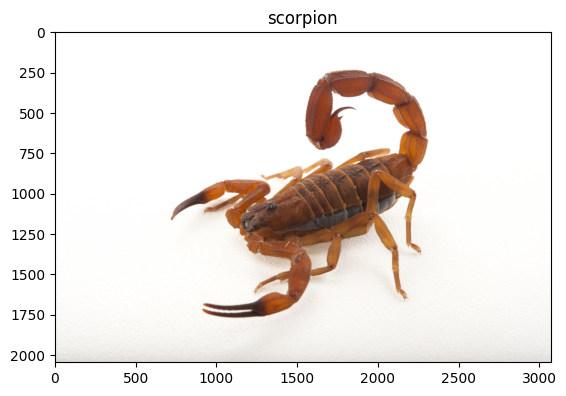

In [ ]:
url = 'https://i.natgeofe.com/n/80d64271-fbea-46cb-8982-13af8c9c0f56/scorpions_03.jpg'
img = np.array(PIL.Image.open(urllib.request.urlopen(url)))
plt.imshow(img)
img = cv2.resize(img, (224, 224))
img = preprocess_input(img)
model = ResNet50()
result = model.predict(img.reshape(1, 224, 224, 3), verbose=False)
plt.title(decode_predictions(result)[0][0][1])

In [ ]:
from keras.utils import plot_model

In [ ]:
plot_model(model, show_layer_activations=True, show_layer_names=True,
           show_shapes=True, show_trainable=True, show_dtype=True)